## Solar Wind Example

This notebook includes a practical example: downloading Parker Solar Probe (PSP) magnetic field data and estimating the power spectral density.

This notebook requires `pyspedas` to download the PSP data.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
from kea.utils import binning
# modify_latex_rc()
# modify_latex_rc()
# Use the GPU for computing the SF, ACF, and performing Gaussian convolutions
from kea.utils import set_calculation_mode
set_calculation_mode(use_cpu=False, use_gpu=True)

Set statistic function calculation flags: (<CalculationMode.USE_GPU: 1>,)


(<CalculationMode.USE_GPU: 1>,)

In [2]:
import pyspedas
time_range = ['2018-11-03/04:15:35', '2018-11-03/04:38:36']
data_names = pyspedas.projects.psp.fields(trange=time_range, time_clip=True)

25-Jun-26 16:39:01: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l2/mag_rtn/2018/
25-Jun-26 16:39:04: Downloading https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l2/mag_rtn/2018/psp_fld_l2_mag_rtn_2018110300_v02.cdf to psp_data/fields/l2/mag_rtn/2018/psp_fld_l2_mag_rtn_2018110300_v02.cdf
25-Jun-26 16:39:33: Download of psp_data/fields/l2/mag_rtn/2018/psp_fld_l2_mag_rtn_2018110300_v02.cdf complete, 69.084 MB in 29.4 sec (2.351 MB/sec) (transfer_normal)
25-Jun-26 16:39:36: Downloading remote index: https://spdf.gsfc.nasa.gov/pub/data/psp/fields/l2/mag_rtn/2018/
25-Jun-26 16:39:38: File is current: psp_data/fields/l2/mag_rtn/2018/psp_fld_l2_mag_rtn_2018110300_v02.cdf


In [3]:
from pyspedas import tplot, get_data
## Load PSP data
data = get_data('psp_fld_l2_mag_RTN')
print(np.shape(data.y))
## Setup grid dimension(s)
# The PSP data we are using is time-series (1D) of magnetic field measurements
D = 1

(202295, 3)


In [4]:
## Get vector components
bx, by, bz = data.y[:,0], data.y[:,1], data.y[:,2]
## Get fluctuations (by subtracting a global mean)
bx = bx - np.nanmean(bx)
by = by - np.nanmean(by)
bz = bz - np.nanmean(bz)

In [5]:
## Load physical domain information
dt = np.nanmean(np.diff(data.times))
L = np.float64(dt * len(data.times))
print(L)
from kea.utils import geometry
geometry.DEFAULT_PHYS_SCALE = L
print(geometry.DEFAULT_PHYS_SCALE)

1381.004167840639
1381.004167840639


In [6]:
## Sub-sample for this example
bx = bx[::32]
by = by[::32]
bz = bz[::32]
N = np.shape(bx)[0]
print(N)
grid_dims = (N,)

6322


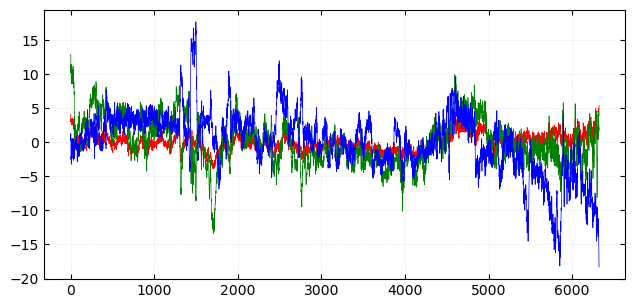

In [7]:
## Plot fluctuation data
fig, ax = plt.subplots(1, 1, figsize=(7.5, 3.5))
ax.plot(bx, linestyle='-', color='red', linewidth=0.5)
ax.plot(by, linestyle='-', color='green', linewidth=0.5)
ax.plot(bz, linestyle='-', color='blue', linewidth=0.5)
pretty_axes(ax)

### Estimate the PSD

Compute PSDs using the different estimates.

Note that since the field is a vector field. We compute the estimate of each component which generates the diagonal of the spectral tensor, and we take the TRACE (i.e., sum).

In [9]:
from kea.statistics.spectra import bin_spectrum, fourier_modal_spectrum, bt_modal_spectrum, esf_integrated_spectrum, transform_spectrum, dog_averaged_spectrum
from kea.statistics.statfunc import complete_symmetric_correlation_function, structure_function

In [10]:
## (FFT)
# Directly compute the power spectrum using the fast Fourier transform
kvecx, fft_spectrumx = fourier_modal_spectrum(bx)
_, fft_spectrumy = fourier_modal_spectrum(by)
_, fft_spectrumz = fourier_modal_spectrum(bz)
# Bin to the angle-averaged (average circular shells)
kp_averaged, fek_averaged, kp_widths = bin_spectrum(kvecx, fft_spectrumx + fft_spectrumy + fft_spectrumz, 'averaged')

25-Jun-26 16:39:54: /home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))



In [11]:
## (BT)
bt_spectrum = None
for field in [bx, by, bz]:
    # First calculate the ACF
    lags, acf_full = complete_symmetric_correlation_function(field)
    # Compute the correlogram
    kvec_bt, _spectrum = bt_modal_spectrum(acf_full)
    if bt_spectrum is None:
        bt_spectrum = _spectrum.copy()
    else:
        bt_spectrum = bt_spectrum + _spectrum
kbt_averaged, fekbt_averaged, _ = bin_spectrum(kvec_bt, bt_spectrum, 'averaged')

25-Jun-26 16:39:55: /home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))



In [20]:
from kea.utils import set_fitting_mode
set_fitting_mode(finite_differences=True)

## (ESF)
# First calculate the structure function
feke_averaged = None
dx, dk = geometry.get_dxdk(grid_dims)
for field in [bx, by, bz]:
    lags, sf2 = structure_function(field)
    sf2 = np.reshape(sf2, (N//2,)*D)*(dx[0]*N)**D
    # Convert the lags that describe the grid indices into lags that represent the physical space
    physical_lags = np.linalg.norm(lags*dx[0], axis=1).reshape((N//2,)*D)
    # Bin the SF
    ell_b, sf2_b, _ = binning.bin_data(physical_lags, sf2, 
        min_bin=dx[0]-dx[0]/2., max_bin=L/2., bin_func=np.nanmean, cut_excess=True, nan_small=False, ignore_nan=True, bin_loc='center')

    ke, biased_esf_spectrum, esf_spectrum = esf_integrated_spectrum(ell_b, sf2_b, 2, np.sqrt(2.), kp_averaged)

    # Convert from the ESF integrated spectrum to the averaged spectrum
    ke_averaged, _spectrum = transform_spectrum(
        ke, esf_spectrum, D, 'integrated', 'averaged', grid_dims, bin_widths=kp_widths, is_centered=True)
    if feke_averaged is None:
        feke_averaged = _spectrum.copy()
    else:
        feke_averaged = feke_averaged + _spectrum

25-Jun-26 17:52:57: /home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))

25-Jun-26 17:52:57: /home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))

25-Jun-26 17:52:57: /home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))



In [16]:
## (DoG)
# Directly compute the DoG spectrum using Gaussian convolutions
dog_spectrum = None
for field in [bx, by, bz]:
    kd, _spectrum = dog_averaged_spectrum(field)
    if dog_spectrum is None:
        dog_spectrum = _spectrum.copy()
    else:
        dog_spectrum = dog_spectrum + _spectrum

Now compare the different techniques

(10.0, 1000000.0)

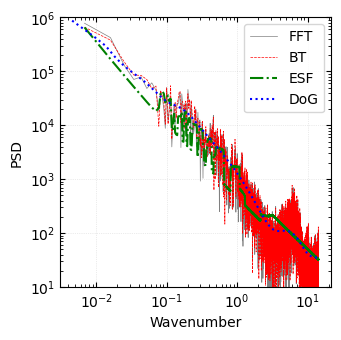

In [21]:
## Plot the PSD
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5))
ax.plot(kp_averaged, fek_averaged, linestyle='-', color='gray', linewidth=0.5, label='FFT')
ax.plot(kbt_averaged, fekbt_averaged, linestyle='--', color='red', linewidth=0.5, label='BT')
ax.plot(ke_averaged, feke_averaged, linestyle='-.', color='green', linewidth=1.5, label='ESF')
ax.plot(kd, dog_spectrum, linestyle=':', color='blue', linewidth=1.5, label='DoG')
pretty_axes(ax)
ax.loglog()
ax.set_ylabel('PSD')
ax.set_xlabel('Wavenumber')
ax.legend()
ax.set_ylim((1e1, 1e6))